Gian Tituaña, 325991.

# NYC Taxi Total Amount Regression: From-Scratch vs Scikit-Learn

## Objetivo
Predecir `total_amount` en el momento del **pickup** (sin data leakage) 


## 1. Setup e Imports

In [1]:
!pip install -q numpy pandas scikit-learn psycopg2-binary matplotlib seaborn

In [2]:
!pip install --upgrade pyarrow pandas

In [3]:
!pip install pyarrow

In [4]:
import numpy as np
import pandas as pd
import psycopg2
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import SGDRegressor, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
from datetime import datetime

warnings.filterwarnings('ignore')
np.random.seed(42)

print('✓ Imports loaded')
print(f'Timestamp: {datetime.now()}')

✓ Imports loaded
Timestamp: 2025-11-12 20:24:46.198102


## 2. Carga de Datos desde PostgreSQL (Split Temporal)

**Estrategia**: Procesar por batches debido al volumen 
- **Train**: 2023 
- **Validación**: 2024 
- **Test**: 2025 

**Features sin leakage** (disponibles en pickup):
- Numéricas: `trip_distance`, `passenger_count`, `pickup_hour`, `day_of_week`, `month`, `year`, `is_weekend`, `is_rush_hour`
- Categóricas (Top-K): `service_type`, `vendor_id`, `rate_code_desc`, `pu_borough`, `pu_zone`

In [5]:
import os

# ============================================================================
# CONFIGURACIÓN POSTGRESQL DESDE VARIABLES DE ENTORNO
# ============================================================================
DB_CONFIG = {
    'host': os.getenv('PG_HOST', 'localhost'),
    'port': int(os.getenv('PG_PORT', 5432)),
    'database': os.getenv('PG_DB', 'postgres'),
    'user': os.getenv('PG_USER', 'postgres'),
    'password': os.getenv('PG_PASSWORD', 'root')
}

print(' Configuración de conexión PostgreSQL:')
print(f'   Host: {DB_CONFIG["host"]}:{DB_CONFIG["port"]}')
print(f'   Database: {DB_CONFIG["database"]}')
print(f'   User: {DB_CONFIG["user"]}')

conn = psycopg2.connect(**DB_CONFIG)
print('✓ Connected to PostgreSQL')


 Configuración de conexión PostgreSQL:
   Host: localhost:5432
   Database: postgres
   User: postgres
✓ Connected to PostgreSQL


###  Sistema de Caché: Cargar Datos Locales o desde BD

**Flujo:**
1. Si existe caché local → cargar desde Parquet (rápido)
2. Si NO existe caché → cargar desde base de datos y guardar caché

In [6]:
# 2.0 Verificar si existe caché local
import os

CACHE_DIR = 'data_cache'
TRAIN_CACHE = os.path.join(CACHE_DIR, 'train_2023.parquet')
VALID_CACHE = os.path.join(CACHE_DIR, 'valid_2024.parquet')
TEST_CACHE = os.path.join(CACHE_DIR, 'test_2025.parquet')

# Variable para controlar si se usa caché
USE_CACHE = all([
    os.path.exists(TRAIN_CACHE),
    os.path.exists(VALID_CACHE),
    os.path.exists(TEST_CACHE)
])

print('='*60)
print('CACHE SYSTEM STATUS')
print('='*60)

if USE_CACHE:
    print(' Cache files found!')
    print(f'   {TRAIN_CACHE}')
    print(f'   {VALID_CACHE}')
    print(f'   {TEST_CACHE}')
    print('\n Will load data from LOCAL CACHE (fast)')
else:
    print(' Cache files NOT found')
    print(f'   Missing: {CACHE_DIR}/*.parquet')
    print('\n Will load data from DATABASE (slower)')
    print('   Cache will be created after loading')

print('='*60)

CACHE SYSTEM STATUS
 Cache files found!
   data_cache\train_2023.parquet
   data_cache\valid_2024.parquet
   data_cache\test_2025.parquet

 Will load data from LOCAL CACHE (fast)


In [7]:
# 2.1 Configuración de carga de datos
# Cambiar a True para pruebas rápidas con 100K registros por año
# False para cargar TODOS los datos (~108M filas)
USE_SAMPLE = False

print(f'Data loading mode: {"SAMPLE (100K per year)" if USE_SAMPLE else "FULL DATA"}')


Data loading mode: FULL DATA


In [8]:
# 2.2 NUEVA FUNCIÓN: Carga optimizada por particiones mensuales

import time
import psycopg2
    
def load_data_in_batches(year, rows_per_month=50000, use_sample=False):

    conn = psycopg2.connect(**DB_CONFIG)
    
    # Query optimizada que accede directamente a partición específica
    # CON MUESTREO ALEATORIO para evitar sesgos
    query_template = """
    SELECT 
        -- Target
        total_amount,
        
        -- Features numéricas
        trip_distance,
        passenger_count,
        pickup_hour,
        day_of_week,
        month,
        year,
        is_weekend::INT as is_weekend,
        is_rush_hour::INT as is_rush_hour,
        
        -- Features categóricas
        service_type,
        vendor_id,
        rate_code_desc,
        pu_borough,
        pu_zone
        
    FROM analytics.obt_trips
    WHERE 
        partition_year = {year}
        AND partition_month = {month}  -- ← Acceso directo a partición específica
        AND total_amount > 0 
        AND total_amount <= 500
        AND trip_distance > 0 
        AND trip_distance < 100
        AND passenger_count > 0
        AND passenger_count <= 6
    ORDER BY RANDOM()  -- ← Muestreo aleatorio para evitar sesgos
    LIMIT {limit}
    """
    
    # Decidir qué meses cargar
    if use_sample:
        months_to_load = [1]  # Solo enero
    else:
        months_to_load = list(range(1, 13))  # Todos los meses
    
    print(f'   Loading {len(months_to_load)} month(s) from {year}, {rows_per_month:,} rows/month')
    
    # Iterar por cada mes
    for month in months_to_load:
        t0 = time.time()
        
        # Formatear query con valores específicos
        query = query_template.format(
            year=year, 
            month=month, 
            limit=rows_per_month
        )
        
        # Ejecutar query
        df = pd.read_sql_query(query, conn)
        elapsed = time.time() - t0
        
        # Reportar resultado
        if len(df) > 0:
            print(f'    ✓ {year}-{month:02d}: {len(df):,} rows loaded in {elapsed:.2f}s')
            yield df  # Entregar este mes y continuar
        else:
            print(f'      {year}-{month:02d}: No data found')
    
    conn.close()

print('='*70)
print(' Función load_data_in_batches() definida correctamente')
print('='*70)
print('Características:')
print('  • Usa particiones por mes (10-50x más rápido que OFFSET)')
print('  • Evita escanear toda la tabla')
print('  • Liberación automática de memoria con yield')
print('  • Default: 50K filas/mes = 600K filas/año')
print('='*70)

 Función load_data_in_batches() definida correctamente
Características:
  • Usa particiones por mes (10-50x más rápido que OFFSET)
  • Evita escanear toda la tabla
  • Liberación automática de memoria con yield
  • Default: 50K filas/mes = 600K filas/año


In [9]:
# 2.3 Cargar datos: DESDE CACHÉ o DESDE BD
print('\n' + '='*60)
print('LOADING DATA')
print('='*60)

import gc
import time

if USE_CACHE:
    # ==========================================
    # OPCIÓN 1: CARGAR DESDE CACHÉ (RÁPIDO)
    # ==========================================
    print('\n Loading from LOCAL CACHE...\n')
    
    start_time = time.time()
    
    # Cargar desde archivos Parquet
    df_train = pd.read_parquet(TRAIN_CACHE)
    print(f'✓ Train loaded: {df_train.shape[0]:,} rows ({time.time() - start_time:.2f}s)')
    
    df_valid = pd.read_parquet(VALID_CACHE)
    print(f'✓ Valid loaded: {df_valid.shape[0]:,} rows ({time.time() - start_time:.2f}s)')
    
    df_test = pd.read_parquet(TEST_CACHE)
    print(f'✓ Test loaded: {df_test.shape[0]:,} rows ({time.time() - start_time:.2f}s)')
    
    total_time = time.time() - start_time
    total_rows = df_train.shape[0] + df_valid.shape[0] + df_test.shape[0]
    
    print(f'\n Total: {total_rows:,} rows loaded in {total_time:.2f}s')
    print(f'   Speed: {total_rows/total_time:,.0f} rows/second')
    
else:
    # ==========================================
    # OPCIÓN 2: CARGAR DESDE BASE DE DATOS
    # ==========================================
    print('\n Loading from DATABASE...\n')
    
    # Decidir cuántos datos cargar
    use_sample_mode = USE_SAMPLE
    rows_per_month = 50000

    if use_sample_mode:
        years_to_load = [2023, 2024, 2025]
    else:
        years_to_load = [2023, 2024, 2025]

    print(f'Mode: {"SAMPLE" if use_sample_mode else "FULL DATASET"}')
    print(f'Years to load: {years_to_load}')

    # Cargar todos los datos en un solo DataFrame
    all_data = []

    for year in years_to_load:
        print(f'\n Loading year {year}...')
        year_batches = []
        
        for batch in load_data_in_batches(year, rows_per_month=rows_per_month, use_sample=use_sample_mode):
            year_batches.append(batch)
        
        # Concatenar batches del año
        if year_batches:
            year_df = pd.concat(year_batches, ignore_index=True)
            all_data.append(year_df)
            print(f'  ✓ Year {year}: {len(year_df):,} records loaded')
            del year_batches
            gc.collect()

    # Concatenar todos los años
    df_all = pd.concat(all_data, ignore_index=True)
    del all_data
    gc.collect()

    print(f'\n✓ Total records loaded: {len(df_all):,}')
    print(f'✓ Memory usage: ~{df_all.memory_usage(deep=True).sum() / (1024**2):.2f} MB')

    # Dividir por año
    df_train = df_all[df_all['year'] == 2023].copy()
    df_valid = df_all[df_all['year'] == 2024].copy()
    df_test = df_all[df_all['year'] == 2025].copy()

    del df_all
    gc.collect()

    print(f'\n✓ Train set (2023): {df_train.shape[0]:,} rows')
    print(f'✓ Valid set (2024): {df_valid.shape[0]:,} rows')
    print(f'✓ Test set (2025): {df_test.shape[0]:,} rows')

print('\n' + '='*60)
print('✓ DATA LOADING COMPLETED')
print('='*60)


LOADING DATA

 Loading from LOCAL CACHE...

✓ Train loaded: 599,778 rows (2.90s)
✓ Valid loaded: 599,731 rows (3.19s)
✓ Test loaded: 449,833 rows (3.47s)

 Total: 1,649,342 rows loaded in 3.47s
   Speed: 475,525 rows/second

✓ DATA LOADING COMPLETED


In [10]:
# 2.5 Verificación de calidad de datos
print('\n' + '='*60)
print('DATA QUALITY CHECK')
print('='*60)

print('\n Train set (2023) - ANTES:')
print(f'  Shape: {df_train.shape}')
print(f'  Missing values: {df_train.isnull().sum().sum()}')
print(f'  Duplicates: {df_train.duplicated().sum()}')

print('\n Validation set (2024) - ANTES:')
print(f'  Shape: {df_valid.shape}')
print(f'  Missing values: {df_valid.isnull().sum().sum()}')
print(f'  Duplicates: {df_valid.duplicated().sum()}')

print('\n Test set (2025) - ANTES:')
print(f'  Shape: {df_test.shape}')
print(f'  Missing values: {df_test.isnull().sum().sum()}')
print(f'  Duplicates: {df_test.duplicated().sum()}')

# Eliminar duplicados en todos los conjuntos
print('\n Eliminando duplicados...')
df_train = df_train.drop_duplicates()
df_valid = df_valid.drop_duplicates()
df_test = df_test.drop_duplicates()

print('\n Train set (2023) - DESPUÉS:')
print(f'  Shape: {df_train.shape}')
print(f'  Missing values: {df_train.isnull().sum().sum()}')
print(f'  Duplicates: {df_train.duplicated().sum()}')

print('\n Validation set (2024) - DESPUÉS:')
print(f'  Shape: {df_valid.shape}')
print(f'  Missing values: {df_valid.isnull().sum().sum()}')
print(f'  Duplicates: {df_valid.duplicated().sum()}')

print('\n Test set (2025) - DESPUÉS:')
print(f'  Shape: {df_test.shape}')
print(f'  Missing values: {df_test.isnull().sum().sum()}')
print(f'  Duplicates: {df_test.duplicated().sum()}')

print('\n Data quality check completed')
print('='*60)


DATA QUALITY CHECK

 Train set (2023) - ANTES:
  Shape: (599778, 14)
  Missing values: 0
  Duplicates: 0

 Validation set (2024) - ANTES:
  Shape: (599731, 14)
  Missing values: 0
  Duplicates: 0

 Test set (2025) - ANTES:
  Shape: (449833, 14)
  Missing values: 0
  Duplicates: 0

 Eliminando duplicados...

 Train set (2023) - DESPUÉS:
  Shape: (599778, 14)
  Missing values: 0
  Duplicates: 0

 Validation set (2024) - DESPUÉS:
  Shape: (599731, 14)
  Missing values: 0
  Duplicates: 0

 Test set (2025) - DESPUÉS:
  Shape: (449833, 14)
  Missing values: 0
  Duplicates: 0

 Data quality check completed


###  Guardar Datos en Caché Local

Para evitar cargar desde la base de datos en cada ejecución, guardamos los datos en formato **Parquet** (rápido y comprimido).

In [11]:
# 2.6 Guardar datos en caché local (Parquet)
import os

# Crear directorio para caché si no existe
CACHE_DIR = 'data_cache'
os.makedirs(CACHE_DIR, exist_ok=True)

# Rutas de archivos
TRAIN_CACHE = os.path.join(CACHE_DIR, 'train_2023.parquet')
VALID_CACHE = os.path.join(CACHE_DIR, 'valid_2024.parquet')
TEST_CACHE = os.path.join(CACHE_DIR, 'test_2025.parquet')

print('='*60)
print('SAVING DATA TO LOCAL CACHE')
print('='*60)

# Guardar cada dataset
df_train.to_parquet(TRAIN_CACHE, index=False, compression='snappy')
print(f'✓ Train saved: {TRAIN_CACHE} ({df_train.shape[0]:,} rows)')

df_valid.to_parquet(VALID_CACHE, index=False, compression='snappy')
print(f'✓ Valid saved: {VALID_CACHE} ({df_valid.shape[0]:,} rows)')

df_test.to_parquet(TEST_CACHE, index=False, compression='snappy')
print(f'✓ Test saved: {TEST_CACHE} ({df_test.shape[0]:,} rows)')

# Calcular tamaño en disco
train_size = os.path.getsize(TRAIN_CACHE) / (1024**2)  # MB
valid_size = os.path.getsize(VALID_CACHE) / (1024**2)
test_size = os.path.getsize(TEST_CACHE) / (1024**2)

print(f'\nCache sizes:')
print(f'  Train: {train_size:.2f} MB')
print(f'  Valid: {valid_size:.2f} MB')
print(f'  Test: {test_size:.2f} MB')
print(f'  Total: {train_size + valid_size + test_size:.2f} MB')

print('\n✓ Data cached successfully!')
print('='*60)

SAVING DATA TO LOCAL CACHE
✓ Train saved: data_cache\train_2023.parquet (599,778 rows)
✓ Valid saved: data_cache\valid_2024.parquet (599,731 rows)
✓ Test saved: data_cache\test_2025.parquet (449,833 rows)

Cache sizes:
  Train: 3.71 MB
  Valid: 3.72 MB
  Test: 2.80 MB
  Total: 10.24 MB

✓ Data cached successfully!


## 3. EDA (Exploratory Data Analysis)

Análisis breve de:
- Distribución del target (`total_amount`)
- Cardinalidad de variables categóricas
- Outliers y valores extremos

TARGET DISTRIBUTION: total_amount
count    599778.000000
mean         28.774917
std          22.522181
min           1.000000
25%          15.960000
50%          21.000000
75%          30.650000
max         495.630005
Name: total_amount, dtype: float64

Skewness: 2.92
Kurtosis: 15.94


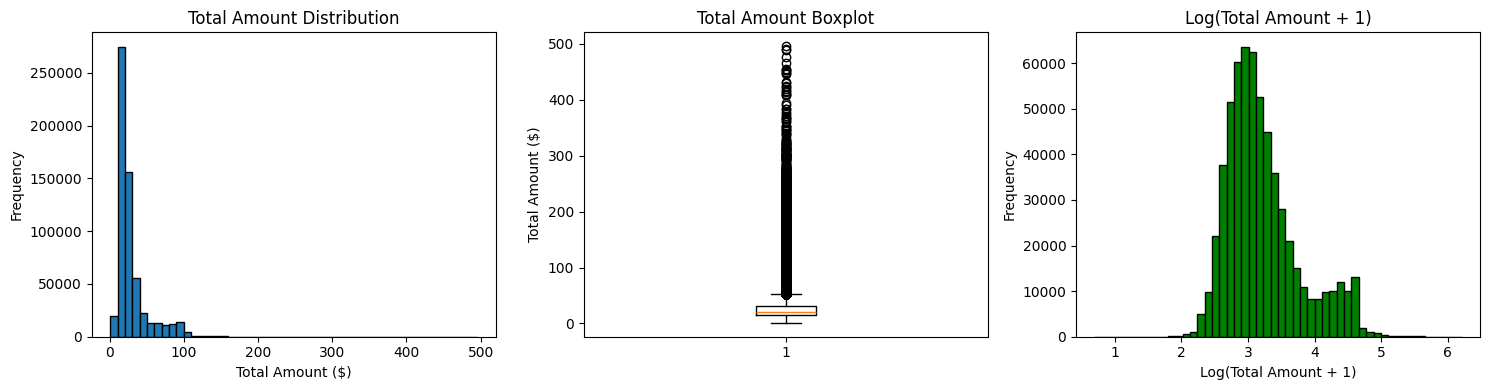

In [12]:
# 3.1 Distribución del target
print('='*60)
print('TARGET DISTRIBUTION: total_amount')
print('='*60)
print(df_train['total_amount'].describe())
print(f'\nSkewness: {df_train["total_amount"].skew():.2f}')
print(f'Kurtosis: {df_train["total_amount"].kurtosis():.2f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histograma
axes[0].hist(df_train['total_amount'], bins=50, edgecolor='black')
axes[0].set_title('Total Amount Distribution')
axes[0].set_xlabel('Total Amount ($)')
axes[0].set_ylabel('Frequency')

# Boxplot
axes[1].boxplot(df_train['total_amount'])
axes[1].set_title('Total Amount Boxplot')
axes[1].set_ylabel('Total Amount ($)')

# Log scale
axes[2].hist(np.log1p(df_train['total_amount']), bins=50, edgecolor='black', color='green')
axes[2].set_title('Log(Total Amount + 1)')
axes[2].set_xlabel('Log(Total Amount + 1)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [13]:
# 3.2 Cardinalidad de variables categóricas
print('\n' + '='*60)
print('CATEGORICAL FEATURES CARDINALITY')
print('='*60)

cat_cols = ['service_type', 'vendor_id', 'rate_code_desc', 'pu_borough', 'pu_zone']

for col in cat_cols:
    n_unique = df_train[col].nunique()
    print(f'\n{col}: {n_unique} unique values')
    print(df_train[col].value_counts().head(10))


CATEGORICAL FEATURES CARDINALITY

service_type: 2 unique values
service_type
yellow    588378
green      11400
Name: count, dtype: int64

vendor_id: 2 unique values
vendor_id
2    453444
1    146334
Name: count, dtype: int64

rate_code_desc: 7 unique values
rate_code_desc
Standard rate            568917
JFK                       23051
Unknown                    3123
Newark                     1884
Negotiated fare            1559
Nassau or Westchester      1243
Group ride                    1
Name: count, dtype: int64

pu_borough: 8 unique values
pu_borough
Manhattan        528207
Queens            61054
Unknown            5196
Brooklyn           4314
Bronx               896
N/A                  71
Staten Island        26
EWR                  14
Name: count, dtype: int64

pu_zone: 241 unique values
pu_zone
JFK Airport                     31271
Upper East Side South           28256
Midtown Center                  27752
Upper East Side North           24764
Midtown East                  


CORRELATION WITH TARGET
total_amount       1.000000
trip_distance      0.942448
passenger_count    0.039756
month              0.028096
pickup_hour        0.019697
is_rush_hour      -0.015064
is_weekend        -0.018986
day_of_week       -0.031129
year                    NaN
Name: total_amount, dtype: float64


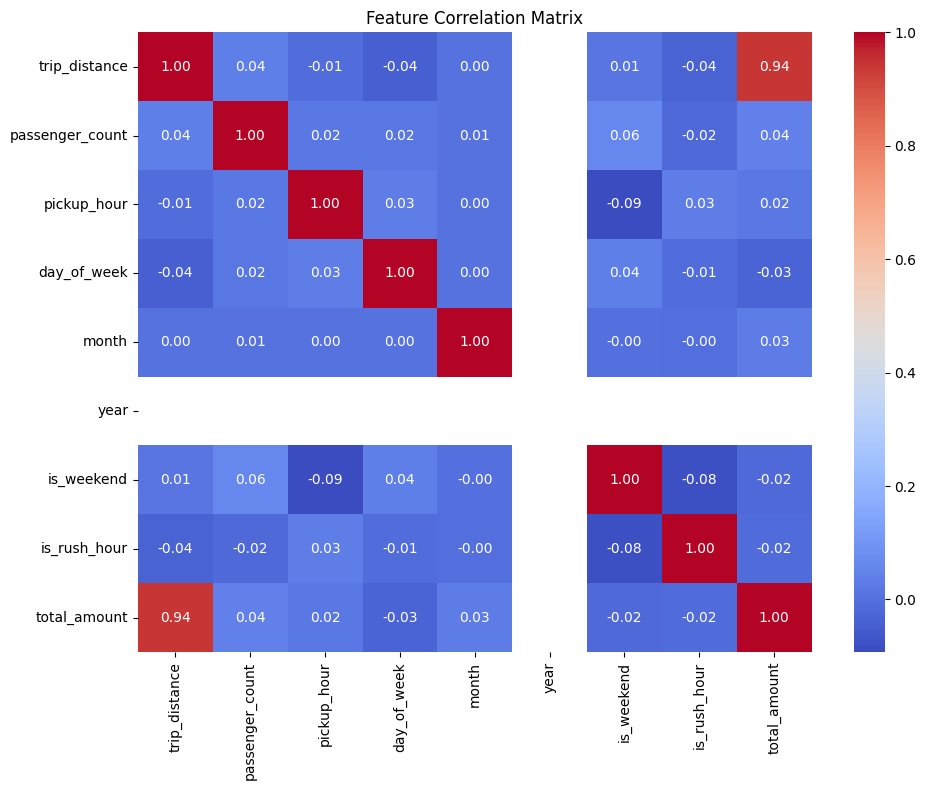

In [14]:
# 3.3 Correlación entre numéricas y target
print('\n' + '='*60)
print('CORRELATION WITH TARGET')
print('='*60)

num_cols = ['trip_distance', 'passenger_count', 'pickup_hour', 'day_of_week', 
            'month', 'year', 'is_weekend', 'is_rush_hour']

correlations = df_train[num_cols + ['total_amount']].corr()['total_amount'].sort_values(ascending=False)
print(correlations)

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_train[num_cols + ['total_amount']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()


NUMERICAL FEATURES STATISTICS
       trip_distance  passenger_count    pickup_hour    day_of_week  \
count  599778.000000    599778.000000  599778.000000  599778.000000   
mean        3.511747         1.390178      14.308416       3.116308   
std         4.554912         0.884343       5.777542       1.953365   
min         0.010000         1.000000       0.000000       0.000000   
25%         1.100000         1.000000      11.000000       1.000000   
50%         1.800000         1.000000      15.000000       3.000000   
75%         3.440000         1.000000      19.000000       5.000000   
max        97.080002         6.000000      23.000000       6.000000   

               month      year     is_weekend   is_rush_hour  
count  599778.000000  599778.0  599778.000000  599778.000000  
mean        6.500150    2023.0       0.270420       0.309314  
std         3.452041       0.0       0.444177       0.462211  
min         1.000000    2023.0       0.000000       0.000000  
25%         4.

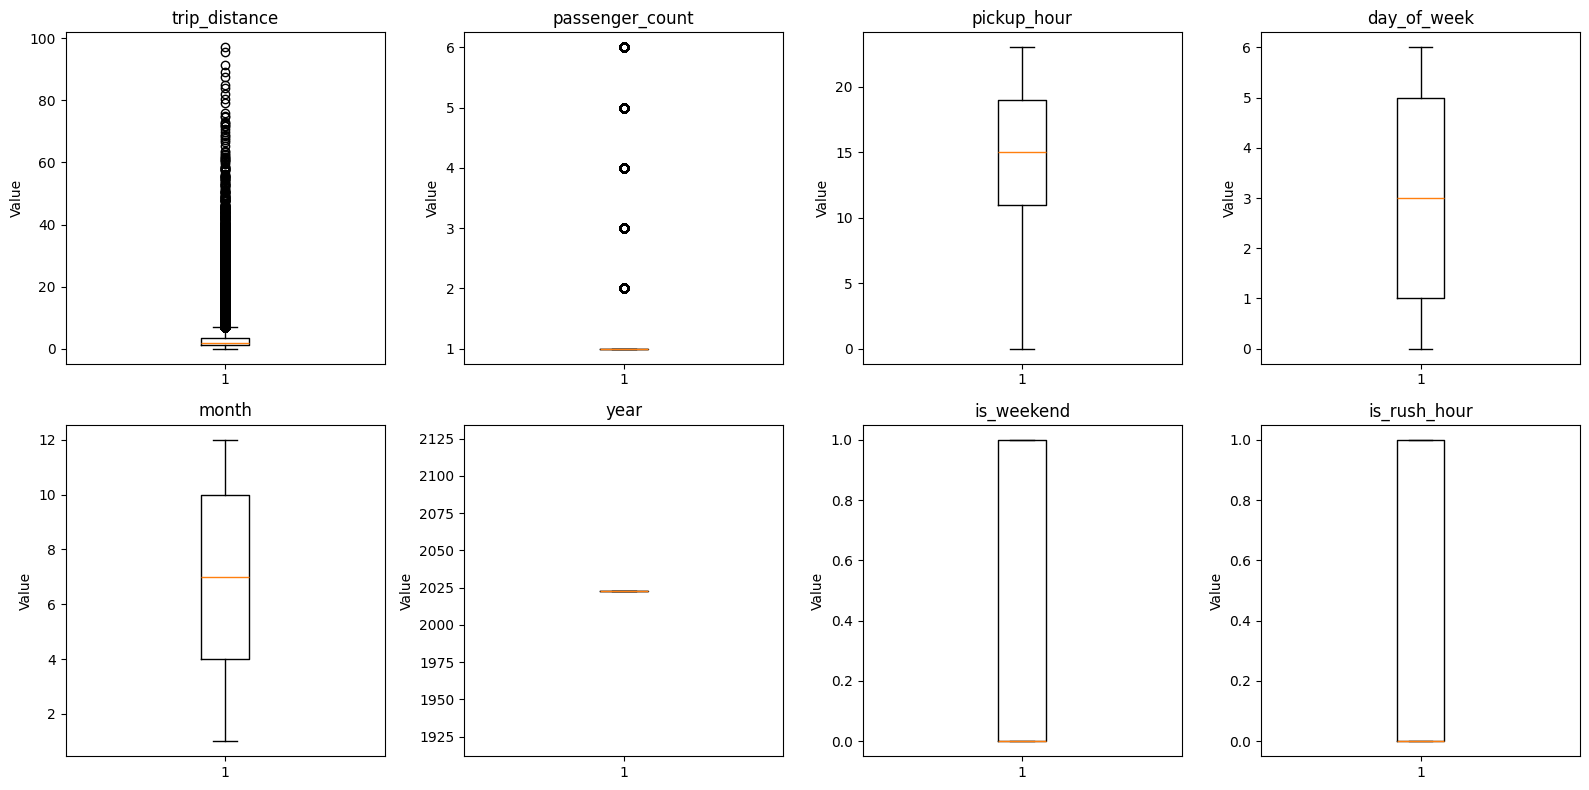

In [15]:
# 3.4 Análisis de outliers en features numéricas
print('\n' + '='*60)
print('NUMERICAL FEATURES STATISTICS')
print('='*60)
print(df_train[num_cols].describe())

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for idx, col in enumerate(num_cols):
    axes[idx].boxplot(df_train[col])
    axes[idx].set_title(col)
    axes[idx].set_ylabel('Value')

plt.tight_layout()
plt.show()

## 4. Feature Engineering y Preprocesamiento

**Decisiones**:
1. **Top-K encoding** para categóricas de alta cardinalidad (pu_zone: Top-20 + "Other")
2. **One-Hot Encoding** para categóricas de baja cardinalidad
3. **StandardScaler** para numéricas (obligatorio para regularización L1/L2/SGD)
4. **PolynomialFeatures** (degree=2) para capturar interacciones
5. **Imputación**: Categóricas → "Unknown", Numéricas → mediana

In [16]:
# 4.1 Limpieza de datos (nulos)
print('='*60)
print('DATA CLEANING')
print('='*60)

# Imputación de nulos
for df in [df_train, df_valid, df_test]:
    # Categóricas: llenar con 'Unknown'
    cat_cols = ['service_type', 'vendor_id', 'rate_code_desc', 'pu_borough', 'pu_zone']
    for col in cat_cols:
        df[col] = df[col].fillna('Unknown')
    
    # Numéricas: llenar con mediana (calculada del train)
    num_cols = ['trip_distance', 'passenger_count', 'pickup_hour', 'day_of_week', 
                'month', 'year', 'is_weekend', 'is_rush_hour']
    for col in num_cols:
        if df[col].isnull().sum() > 0:
            median_val = df_train[col].median()
            df[col] = df[col].fillna(median_val)

print(f'✓ Train nulls: {df_train.isnull().sum().sum()}')
print(f'✓ Valid nulls: {df_valid.isnull().sum().sum()}')
print(f'✓ Test nulls: {df_test.isnull().sum().sum()}')

DATA CLEANING
✓ Train nulls: 0
✓ Valid nulls: 0
✓ Test nulls: 0


In [17]:
# 4.2 Top-K Encoding para pu_zone (alta cardinalidad)
print('\n' + '='*60)
print('TOP-K ENCODING (pu_zone)')
print('='*60)

TOP_K = 20

# Identificar Top-K zonas más frecuentes en Train
top_zones = df_train['pu_zone'].value_counts().head(TOP_K).index.tolist()
print(f'Top-{TOP_K} zones: {top_zones[:5]}... (showing first 5)')

# Aplicar Top-K a todos los conjuntos
for df in [df_train, df_valid, df_test]:
    df['pu_zone_topk'] = df['pu_zone'].apply(lambda x: x if x in top_zones else 'Other')

print(f'\n✓ Reduced cardinality: {df_train["pu_zone"].nunique()} → {df_train["pu_zone_topk"].nunique()}')


TOP-K ENCODING (pu_zone)
Top-20 zones: ['JFK Airport', 'Upper East Side South', 'Midtown Center', 'Upper East Side North', 'Midtown East']... (showing first 5)

✓ Reduced cardinality: 241 → 21


In [18]:
# 4.3 Separar features y target
print('\n' + '='*60)
print('FEATURE/TARGET SPLIT')
print('='*60)

# Features numéricas y categóricas
num_features = ['trip_distance', 'passenger_count', 'pickup_hour', 'day_of_week', 
                'month', 'year', 'is_weekend', 'is_rush_hour']

cat_features = ['service_type', 'vendor_id', 'rate_code_desc', 'pu_borough', 'pu_zone_topk']

# Separar X e y (usando target ORIGINAL, sin transformación)
X_train = df_train[num_features + cat_features].copy()
y_train = df_train['total_amount'].copy()

X_valid = df_valid[num_features + cat_features].copy()
y_valid = df_valid['total_amount'].copy()

X_test = df_test[num_features + cat_features].copy()
y_test = df_test['total_amount'].copy()

print(f'✓ X_train: {X_train.shape}')
print(f'✓ X_valid: {X_valid.shape}')
print(f'✓ X_test: {X_test.shape}')
print(f'\nFeatures: {len(num_features)} numerical + {len(cat_features)} categorical')
print(f'\n Using ORIGINAL target: total_amount (without log transformation)')



FEATURE/TARGET SPLIT
✓ X_train: (599778, 13)
✓ X_valid: (599731, 13)
✓ X_test: (449833, 13)

Features: 8 numerical + 5 categorical

 Using ORIGINAL target: total_amount (without log transformation)


In [19]:
# 4.4 Preprocesamiento con Pipeline
print('\n' + '='*60)
print('PREPROCESSING PIPELINE')
print('='*60)

# Convertir categóricas a string (necesario para OneHotEncoder)
for col in cat_features:
    X_train[col] = X_train[col].astype(str)
    X_valid[col] = X_valid[col].astype(str)
    X_test[col] = X_test[col].astype(str)

# Column Transformer: Scale numéricas + OHE categóricas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
    ],
    remainder='drop'
)

# Fit en Train, transform en Train/Valid/Test
X_train_prep = preprocessor.fit_transform(X_train)
X_valid_prep = preprocessor.transform(X_valid)
X_test_prep = preprocessor.transform(X_test)

print(f'✓ X_train_prep: {X_train_prep.shape}')
print(f'✓ X_valid_prep: {X_valid_prep.shape}')
print(f'✓ X_test_prep: {X_test_prep.shape}')
print(f'\n✓ After OHE: {X_train_prep.shape[1]} features')


PREPROCESSING PIPELINE
✓ X_train_prep: (599778, 48)
✓ X_valid_prep: (599731, 48)
✓ X_test_prep: (449833, 48)

✓ After OHE: 48 features


In [20]:
# 4.5 Polynomial Features SOLO para trip_distance y pickup_hour
print('\n' + '='*60)
print('POLYNOMIAL FEATURES: STRATEGIC APPROACH')
print('='*60)

trip_distance_idx = 0  # Primera columna numérica
pickup_hour_idx = 2    # Tercera columna numérica

print(f'Original features: {X_train_prep.shape[1]}')
print(f'  - Numéricas escaladas: 8')
print(f'  - Categóricas OHE: {X_train_prep.shape[1] - 8}')

# Extraer solo trip_distance y pickup_hour
X_train_poly_input = X_train_prep[:, [trip_distance_idx, pickup_hour_idx]]
X_valid_poly_input = X_valid_prep[:, [trip_distance_idx, pickup_hour_idx]]
X_test_poly_input = X_test_prep[:, [trip_distance_idx, pickup_hour_idx]]

print(f'\nExtracting features for polynomial transformation:')
print(f'  - trip_distance (idx {trip_distance_idx})')
print(f'  - pickup_hour (idx {pickup_hour_idx})')

# Crear features polinomiales (degree=2): x1, x2, x1², x1×x2, x2²
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly_features = poly.fit_transform(X_train_poly_input)
X_valid_poly_features = poly.transform(X_valid_poly_input)
X_test_poly_features = poly.transform(X_test_poly_input)

print(f'\nPolynomial features created: {X_train_poly_features.shape[1]} columns')
print(f'  Feature names: {poly.get_feature_names_out(["trip_distance", "pickup_hour"])}')

# Las primeras 2 columnas (trip_distance, pickup_hour) ya están en X_train_prep
# Solo agregamos las 3 nuevas: trip_distance², trip_distance×pickup_hour, pickup_hour²
X_train_poly_new = X_train_poly_features[:, 2:]  # Excluir las 2 primeras (ya existen)
X_valid_poly_new = X_valid_poly_features[:, 2:]
X_test_poly_new = X_test_poly_features[:, 2:]

print(f'\nNew polynomial-only features: {X_train_poly_new.shape[1]} columns')

# Concatenar con todas las features originales
X_train_final = np.hstack([X_train_prep, X_train_poly_new])
X_valid_final = np.hstack([X_valid_prep, X_valid_poly_new])
X_test_final = np.hstack([X_test_prep, X_test_poly_new])

print(f'\n✓ Final feature count: {X_train_final.shape[1]}')
print(f'  = {X_train_prep.shape[1]} (original) + {X_train_poly_new.shape[1]} (polynomial)')

# Reemplazar variables preprocesadas
X_train_prep = X_train_final
X_valid_prep = X_valid_final
X_test_prep = X_test_final

print(f'\n✓ Polynomial features added successfully')
print(f'✓ Memory-efficient: only {X_train_poly_new.shape[1]} new columns added')


POLYNOMIAL FEATURES: STRATEGIC APPROACH
Original features: 48
  - Numéricas escaladas: 8
  - Categóricas OHE: 40

Extracting features for polynomial transformation:
  - trip_distance (idx 0)
  - pickup_hour (idx 2)

Polynomial features created: 5 columns
  Feature names: ['trip_distance' 'pickup_hour' 'trip_distance^2'
 'trip_distance pickup_hour' 'pickup_hour^2']

New polynomial-only features: 3 columns

✓ Final feature count: 51
  = 48 (original) + 3 (polynomial)

✓ Polynomial features added successfully
✓ Memory-efficient: only 3 new columns added


## 5. Baseline Model

Modelo simple para comparación: Media del target


In [21]:
print('='*60)
print('BASELINE: MEAN PREDICTOR')
print('='*60)

# Predecir siempre la media del train
y_pred_baseline = np.full_like(y_valid, y_train.mean())

# Métricas
rmse_baseline = np.sqrt(mean_squared_error(y_valid, y_pred_baseline))
mae_baseline = mean_absolute_error(y_valid, y_pred_baseline)
r2_baseline = r2_score(y_valid, y_pred_baseline)

print(f'Train mean: ${y_train.mean():.2f}')

print(f'\nValidation Metrics:')
print(f'  RMSE: ${rmse_baseline:.4f}')
print(f'  MAE:  ${mae_baseline:.4f}')
print(f'  R²:   {r2_baseline:.4f}')

print('\n✓ Baseline established')


BASELINE: MEAN PREDICTOR
Train mean: $28.77

Validation Metrics:
  RMSE: $22.8112
  MAE:  $15.0002
  R²:   -0.0000

✓ Baseline established


## 6. From-Scratch Models (NumPy Implementation)

Implementación de 4 modelos con regularización:
1. **SGD** (Stochastic Gradient Descent)
2. **Ridge** (L2)
3. **Lasso** (L1) - usando coordinate descent
4. **ElasticNet** (L1 + L2)

Todos con **early stopping** para evitar overfitting.

In [22]:
# 6.1 SGD From-Scratch con Early Stopping
class SGDRegressorFromScratch:
    """Stochastic Gradient Descent con L2 regularization y early stopping"""
    
    def __init__(self, learning_rate=0.01, alpha=0.0001, max_iter=1000, 
                 tol=1e-4, early_stopping=True, validation_fraction=0.1, 
                 n_iter_no_change=10, random_state=42):
        self.learning_rate = learning_rate
        self.alpha = alpha  # L2 regularization
        self.max_iter = max_iter
        self.tol = tol
        self.early_stopping = early_stopping
        self.validation_fraction = validation_fraction
        self.n_iter_no_change = n_iter_no_change
        self.random_state = random_state
        self.coef_ = None
        self.intercept_ = None
        self.training_loss_ = []
        self.validation_loss_ = []
        
    def fit(self, X, y):
        np.random.seed(self.random_state)
        n_samples, n_features = X.shape
        
        # Inicializar pesos
        self.coef_ = np.zeros(n_features)
        self.intercept_ = 0.0
        
        # Initialize best weights to current weights to avoid unbound variable
        best_coef = self.coef_.copy()
        best_intercept = self.intercept_
        
        # Early stopping split (only if validation_fraction produces at least 1 sample)
        if self.early_stopping:
            val_size = int(n_samples * self.validation_fraction)
            if val_size > 0:
                indices = np.random.permutation(n_samples)
                X_train_es = X[indices[val_size:]]
                y_train_es = y[indices[val_size:]]
                X_val_es = X[indices[:val_size]]
                y_val_es = y[indices[:val_size]]
            else:
                # Disable early stopping if validation set would be empty
                self.early_stopping = False
                X_train_es = X
                y_train_es = y
        else:
            X_train_es = X
            y_train_es = y
        
        best_loss = np.inf
        no_improvement = 0
        
        for epoch in range(self.max_iter):
            # Shuffle data
            indices = np.random.permutation(len(X_train_es))
            X_shuffled = X_train_es[indices]
            y_shuffled = y_train_es[indices]
            
            # SGD: actualizar por cada muestra
            for i in range(len(X_shuffled)):
                xi = X_shuffled[i:i+1]
                yi = y_shuffled[i:i+1]
                
                # Predicción
                pred = xi @ self.coef_ + self.intercept_
                error = pred - yi
                
                # Gradientes con L2 regularization
                grad_coef = xi.T @ error + self.alpha * self.coef_
                grad_intercept = error
                
                # Update
                self.coef_ -= self.learning_rate * grad_coef.ravel()
                self.intercept_ -= self.learning_rate * grad_intercept[0]
            
            # Calcular loss
            train_pred = X_train_es @ self.coef_ + self.intercept_
            train_loss = np.mean((train_pred - y_train_es) ** 2)
            self.training_loss_.append(train_loss)
            
            if self.early_stopping:
                # Only compute validation loss if validation set exists
                if len(X_val_es) > 0:
                    val_pred = X_val_es @ self.coef_ + self.intercept_
                    val_loss = np.mean((val_pred - y_val_es) ** 2)
                else:
                    val_loss = np.inf
                self.validation_loss_.append(val_loss)
                
                # Early stopping check
                if val_loss < best_loss - self.tol:
                    best_loss = val_loss
                    no_improvement = 0
                    best_coef = self.coef_.copy()
                    best_intercept = self.intercept_
                else:
                    no_improvement += 1
                
                if no_improvement >= self.n_iter_no_change:
                    print(f'  Early stopping at epoch {epoch+1}')
                    # Restore best seen weights
                    self.coef_ = best_coef
                    self.intercept_ = best_intercept
                    break
            
            if (epoch + 1) % 100 == 0:
                print(f'  Epoch {epoch+1}/{self.max_iter}, Loss: {train_loss:.4f}')
        
        return self
    
    def predict(self, X):
        return X @ self.coef_ + self.intercept_

print('✓ SGDRegressorFromScratch defined')

✓ SGDRegressorFromScratch defined


In [23]:
# 6.2 Ridge From-Scratch (L2 Regularization)
class RidgeFromScratch:
    """Ridge Regression usando Normal Equation con L2 regularization"""
    
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        # Añadir columna de 1s para el intercept
        X_with_bias = np.c_[np.ones((n_samples, 1)), X]
        
        # Ridge: (X^T X + alpha*I)^-1 X^T y
        I = np.eye(n_features + 1)
        I[0, 0] = 0  # No regularizar el intercept
        
        try:
            weights = np.linalg.inv(X_with_bias.T @ X_with_bias + self.alpha * I) @ X_with_bias.T @ y
        except:
            weights = np.linalg.pinv(X_with_bias.T @ X_with_bias + self.alpha * I) @ X_with_bias.T @ y
        
        self.intercept_ = weights[0]
        self.coef_ = weights[1:]
        
        return self
    
    def predict(self, X):
        return X @ self.coef_ + self.intercept_

print('✓ RidgeFromScratch defined')

✓ RidgeFromScratch defined


In [24]:
# 6.3 Lasso From-Scratch (L1 Regularization) - Coordinate Descent
class LassoFromScratch:
    """Lasso Regression usando Coordinate Descent con L1 regularization"""
    
    def __init__(self, alpha=1.0, max_iter=1000, tol=1e-4):
        self.alpha = alpha
        self.max_iter = max_iter
        self.tol = tol
        self.coef_ = None
        self.intercept_ = None
    
    def soft_threshold(self, rho, lambda_):
        """Soft thresholding operator para L1"""
        if rho < -lambda_:
            return rho + lambda_
        elif rho > lambda_:
            return rho - lambda_
        else:
            return 0.0
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        # Inicializar
        self.coef_ = np.zeros(n_features)
        self.intercept_ = np.mean(y)
        
        # Coordinate Descent
        for iteration in range(self.max_iter):
            coef_old = self.coef_.copy()
            
            for j in range(n_features):
                # Calcular residual sin feature j
                r = y - (X @ self.coef_ + self.intercept_)
                r += self.coef_[j] * X[:, j]
                
                # Update coefficient j
                rho = X[:, j] @ r
                z = X[:, j] @ X[:, j]
                
                if z != 0:
                    self.coef_[j] = self.soft_threshold(rho, self.alpha * n_samples) / z
                else:
                    self.coef_[j] = 0.0
            
            # Update intercept
            self.intercept_ = np.mean(y - X @ self.coef_)
            
            # Check convergence
            if np.sum(np.abs(self.coef_ - coef_old)) < self.tol:
                print(f'  Converged at iteration {iteration+1}')
                break
        
        return self
    
    def predict(self, X):
        return X @ self.coef_ + self.intercept_

print('✓ LassoFromScratch defined')

✓ LassoFromScratch defined


In [25]:
# 6.4 ElasticNet From-Scratch (L1 + L2)
class ElasticNetFromScratch:
    """ElasticNet Regression (L1 + L2) usando Coordinate Descent"""
    
    def __init__(self, alpha=1.0, l1_ratio=0.5, max_iter=1000, tol=1e-4):
        self.alpha = alpha
        self.l1_ratio = l1_ratio  # Peso de L1 (0=Ridge, 1=Lasso)
        self.max_iter = max_iter
        self.tol = tol
        self.coef_ = None
        self.intercept_ = None
    
    def soft_threshold(self, rho, lambda_):
        """Soft thresholding operator"""
        if rho < -lambda_:
            return rho + lambda_
        elif rho > lambda_:
            return rho - lambda_
        else:
            return 0.0
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        # Inicializar
        self.coef_ = np.zeros(n_features)
        self.intercept_ = np.mean(y)
        
        # Pesos de L1 y L2
        l1_weight = self.alpha * self.l1_ratio
        l2_weight = self.alpha * (1 - self.l1_ratio)
        
        # Coordinate Descent
        for iteration in range(self.max_iter):
            coef_old = self.coef_.copy()
            
            for j in range(n_features):
                # Residual sin feature j
                r = y - (X @ self.coef_ + self.intercept_)
                r += self.coef_[j] * X[:, j]
                
                # Update coefficient j
                rho = X[:, j] @ r
                z = X[:, j] @ X[:, j] + l2_weight * n_samples
                
                if z != 0:
                    self.coef_[j] = self.soft_threshold(rho, l1_weight * n_samples) / z
                else:
                    self.coef_[j] = 0.0
            
            # Update intercept
            self.intercept_ = np.mean(y - X @ self.coef_)
            
            # Check convergence
            if np.sum(np.abs(self.coef_ - coef_old)) < self.tol:
                print(f'  Converged at iteration {iteration+1}')
                break
        
        return self
    
    def predict(self, X):
        return X @ self.coef_ + self.intercept_

print('✓ ElasticNetFromScratch defined')

✓ ElasticNetFromScratch defined


## 7. Training From-Scratch Models con GridSearch

Entrenar los 4 modelos from-scratch con búsqueda de hiperparámetros manual.

In [26]:
# 7.1 GridSearch manual para SGD
print('='*60)
print('TRAINING: SGD FROM-SCRATCH')
print('='*60)

sgd_params = {
    'learning_rate': [0.001, 0.01],
    'alpha': [0.0001, 0.001, 0.01]
}

best_sgd_score = np.inf
best_sgd_params = None
best_sgd_model = None

sgd_results = []

for lr in sgd_params['learning_rate']:
    for alpha in sgd_params['alpha']:
        print(f'\nTrying lr={lr}, alpha={alpha}')
        
        start_time = time.time()
        model = SGDRegressorFromScratch(
            learning_rate=lr,
            alpha=alpha,
            max_iter=500,
            early_stopping=True,
            n_iter_no_change=20,
            random_state=42
        )
        # Entrenar con target original
        model.fit(X_train_prep, y_train.values)
        train_time = time.time() - start_time
        
        # Evaluar en validación
        y_pred = model.predict(X_valid_prep)
        
        # Métricas
        rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
        mae = mean_absolute_error(y_valid, y_pred)
        r2 = r2_score(y_valid, y_pred)
        
        sgd_results.append({
            'lr': lr,
            'alpha': alpha,
            'rmse': rmse,
            'mae': mae,
            'r2': r2,
            'time': train_time
        })
        
        print(f'  RMSE: ${rmse:.4f}, MAE: ${mae:.4f}, R²: {r2:.4f}, Time: {train_time:.2f}s')
        
        if rmse < best_sgd_score:
            best_sgd_score = rmse
            best_sgd_params = {'learning_rate': lr, 'alpha': alpha}
            best_sgd_model = model

print(f'\n✓ Best SGD params: {best_sgd_params}')
print(f'✓ Best RMSE: ${best_sgd_score:.4f}')


TRAINING: SGD FROM-SCRATCH

Trying lr=0.001, alpha=0.0001
  Early stopping at epoch 66
  RMSE: $6.8533, MAE: $3.9672, R²: 0.9097, Time: 884.72s

Trying lr=0.001, alpha=0.001
  Early stopping at epoch 37
  RMSE: $6.8881, MAE: $3.9973, R²: 0.9088, Time: 461.90s

Trying lr=0.001, alpha=0.01
  Early stopping at epoch 32
  RMSE: $7.2897, MAE: $4.1119, R²: 0.8979, Time: 479.21s

Trying lr=0.01, alpha=0.0001
  Early stopping at epoch 21
  RMSE: $4873853185363028422894884020879753312654562538834362368.0000, MAE: $2971098112502272033157700758634809071960412752686612480.0000, R²: -45652588468729741774290155635716000087936036268823310049741124303158899680798553818589620983784542675402752.0000, Time: 319.19s

Trying lr=0.01, alpha=0.001
  Early stopping at epoch 21
  RMSE: $56026400598428942403219322598923412745367454929125376.0000, MAE: $34153314491453914591720346550257723951143074731655168.0000, R²: -603261994376767238808932338414075423846788543740621202546903449580737474478005118203949920984391

In [27]:
# 7.2 GridSearch manual para Ridge
print('\n' + '='*60)
print('TRAINING: RIDGE FROM-SCRATCH')
print('='*60)

ridge_params = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}

best_ridge_score = np.inf
best_ridge_params = None
best_ridge_model = None

ridge_results = []

for alpha in ridge_params['alpha']:
    print(f'\nTrying alpha={alpha}')
    
    start_time = time.time()
    model = RidgeFromScratch(alpha=alpha)
    model.fit(X_train_prep, y_train.values)
    train_time = time.time() - start_time
    
    # Evaluar
    y_pred = model.predict(X_valid_prep)
    
    rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
    mae = mean_absolute_error(y_valid, y_pred)
    r2 = r2_score(y_valid, y_pred)
    
    ridge_results.append({
        'alpha': alpha,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'time': train_time
    })
    
    print(f'  RMSE: ${rmse:.4f}, MAE: ${mae:.4f}, R²: {r2:.4f}, Time: {train_time:.2f}s')
    
    if rmse < best_ridge_score:
        best_ridge_score = rmse
        best_ridge_params = {'alpha': alpha}
        best_ridge_model = model

print(f'\n✓ Best Ridge params: {best_ridge_params}')
print(f'✓ Best RMSE: ${best_ridge_score:.4f}')



TRAINING: RIDGE FROM-SCRATCH

Trying alpha=0.01
  RMSE: $6.7730, MAE: $3.9673, R²: 0.9118, Time: 0.79s

Trying alpha=0.1
  RMSE: $6.7730, MAE: $3.9673, R²: 0.9118, Time: 0.71s

Trying alpha=1.0
  RMSE: $6.7731, MAE: $3.9673, R²: 0.9118, Time: 0.58s

Trying alpha=10.0
  RMSE: $6.7738, MAE: $3.9673, R²: 0.9118, Time: 0.70s

Trying alpha=100.0
  RMSE: $6.7826, MAE: $3.9674, R²: 0.9116, Time: 0.60s

✓ Best Ridge params: {'alpha': 0.01}
✓ Best RMSE: $6.7730


In [28]:
# 7.3 GridSearch manual para Lasso
print('\n' + '='*60)
print('TRAINING: LASSO FROM-SCRATCH')
print('='*60)

lasso_params = {'alpha': [0.01, 0.1, 1.0, 10.0]}

best_lasso_score = np.inf
best_lasso_params = None
best_lasso_model = None

lasso_results = []

for alpha in lasso_params['alpha']:
    print(f'\nTrying alpha={alpha}')
    
    start_time = time.time()
    model = LassoFromScratch(alpha=alpha, max_iter=1000)
    model.fit(X_train_prep, y_train.values)
    train_time = time.time() - start_time
    
    # Evaluar
    y_pred = model.predict(X_valid_prep)
    
    rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
    mae = mean_absolute_error(y_valid, y_pred)
    r2 = r2_score(y_valid, y_pred)
    
    lasso_results.append({
        'alpha': alpha,
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'time': train_time
    })
    
    print(f'  RMSE: ${rmse:.4f}, MAE: ${mae:.4f}, R²: {r2:.4f}, Time: {train_time:.2f}s')
    
    if rmse < best_lasso_score:
        best_lasso_score = rmse
        best_lasso_params = {'alpha': alpha}
        best_lasso_model = model

print(f'\n✓ Best Lasso params: {best_lasso_params}')
print(f'✓ Best RMSE: ${best_lasso_score:.4f}')



TRAINING: LASSO FROM-SCRATCH

Trying alpha=0.01
  Converged at iteration 395
  RMSE: $6.8219, MAE: $3.9733, R²: 0.9106, Time: 771.67s

Trying alpha=0.1
  Converged at iteration 30
  RMSE: $7.6771, MAE: $4.2246, R²: 0.8867, Time: 65.58s

Trying alpha=1.0
  Converged at iteration 8
  RMSE: $8.1569, MAE: $4.6880, R²: 0.8721, Time: 15.98s

Trying alpha=10.0
  Converged at iteration 24
  RMSE: $14.9367, MAE: $10.4307, R²: 0.5712, Time: 55.17s

✓ Best Lasso params: {'alpha': 0.01}
✓ Best RMSE: $6.8219


In [29]:
# 7.4 GridSearch manual para ElasticNet
print('\n' + '='*60)
print('TRAINING: ELASTICNET FROM-SCRATCH')
print('='*60)

enet_params = {
    'alpha': [0.1, 1.0, 10.0],
    'l1_ratio': [0.3, 0.5, 0.7]
}

best_enet_score = np.inf
best_enet_params = None
best_enet_model = None

enet_results = []

for alpha in enet_params['alpha']:
    for l1_ratio in enet_params['l1_ratio']:
        print(f'\nTrying alpha={alpha}, l1_ratio={l1_ratio}')
        
        start_time = time.time()
        model = ElasticNetFromScratch(alpha=alpha, l1_ratio=l1_ratio, max_iter=1000)
        model.fit(X_train_prep, y_train.values)
        train_time = time.time() - start_time
        
        # Evaluar
        y_pred = model.predict(X_valid_prep)
        
        rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
        mae = mean_absolute_error(y_valid, y_pred)
        r2 = r2_score(y_valid, y_pred)
        
        enet_results.append({
            'alpha': alpha,
            'l1_ratio': l1_ratio,
            'rmse': rmse,
            'mae': mae,
            'r2': r2,
            'time': train_time
        })
        
        print(f'  RMSE: ${rmse:.4f}, MAE: ${mae:.4f}, R²: {r2:.4f}, Time: {train_time:.2f}s')
        
        if rmse < best_enet_score:
            best_enet_score = rmse
            best_enet_params = {'alpha': alpha, 'l1_ratio': l1_ratio}
            best_enet_model = model

print(f'\n✓ Best ElasticNet params: {best_enet_params}')
print(f'✓ Best RMSE: ${best_enet_score:.4f}')



TRAINING: ELASTICNET FROM-SCRATCH

Trying alpha=0.1, l1_ratio=0.3


  Converged at iteration 122
  RMSE: $8.0308, MAE: $4.7351, R²: 0.8761, Time: 227.59s

Trying alpha=0.1, l1_ratio=0.5
  Converged at iteration 138
  RMSE: $7.9131, MAE: $4.5864, R²: 0.8797, Time: 226.89s

Trying alpha=0.1, l1_ratio=0.7
  Converged at iteration 111
  RMSE: $7.8041, MAE: $4.4292, R²: 0.8830, Time: 200.81s

Trying alpha=1.0, l1_ratio=0.3
  Converged at iteration 20
  RMSE: $11.6421, MAE: $7.8075, R²: 0.7395, Time: 34.50s

Trying alpha=1.0, l1_ratio=0.5
  Converged at iteration 24
  RMSE: $11.0482, MAE: $7.3132, R²: 0.7654, Time: 43.23s

Trying alpha=1.0, l1_ratio=0.7
  Converged at iteration 22
  RMSE: $10.1772, MAE: $6.5725, R²: 0.8009, Time: 41.78s

Trying alpha=10.0, l1_ratio=0.3
  Converged at iteration 6
  RMSE: $16.5165, MAE: $11.6399, R²: 0.4757, Time: 10.32s

Trying alpha=10.0, l1_ratio=0.5
  Converged at iteration 7
  RMSE: $16.2828, MAE: $11.4797, R²: 0.4905, Time: 12.65s

Trying alpha=10.0, l1_ratio=0.7
  Converged at iteration 8
  RMSE: $16.0049, MAE: $11.2775

## 8. Scikit-Learn Models con GridSearchCV

Entrenar los 4 modelos equivalentes de scikit-learn con el mismo preprocesamiento.

In [30]:
# 8.1 SGDRegressor con GridSearchCV
print('='*60)
print('TRAINING: SGDRegressor (Scikit-Learn)')
print('='*60)

from sklearn.model_selection import GridSearchCV

sgd_sklearn = SGDRegressor(
    loss='squared_error',
    penalty='l2',
    max_iter=500,
    early_stopping=True,
    n_iter_no_change=20,
    random_state=42
)

sgd_param_grid = {
    'learning_rate': ['constant'],
    'eta0': [0.001, 0.01],
    'alpha': [0.0001, 0.001, 0.01]
}

start_time = time.time()
sgd_grid = GridSearchCV(
    sgd_sklearn,
    sgd_param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
sgd_grid.fit(X_train_prep, y_train.values)
sgd_train_time = time.time() - start_time

print(f'\n✓ Best params: {sgd_grid.best_params_}')
print(f'✓ Best CV RMSE: ${-sgd_grid.best_score_:.4f}')
print(f'✓ Training time: {sgd_train_time:.2f}s')

# Evaluar en validación
y_pred_sgd_sklearn = sgd_grid.predict(X_valid_prep)

rmse_sgd_sklearn = np.sqrt(mean_squared_error(y_valid, y_pred_sgd_sklearn))
mae_sgd_sklearn = mean_absolute_error(y_valid, y_pred_sgd_sklearn)
r2_sgd_sklearn = r2_score(y_valid, y_pred_sgd_sklearn)

print(f'\nValidation Metrics:')
print(f'  RMSE: ${rmse_sgd_sklearn:.4f}')
print(f'  MAE:  ${mae_sgd_sklearn:.4f}')
print(f'  R²:   {r2_sgd_sklearn:.4f}')


TRAINING: SGDRegressor (Scikit-Learn)
Fitting 3 folds for each of 6 candidates, totalling 18 fits

✓ Best params: {'alpha': 0.001, 'eta0': 0.001, 'learning_rate': 'constant'}
✓ Best CV RMSE: $6.6158
✓ Training time: 68.47s

Validation Metrics:
  RMSE: $7.0666
  MAE:  $4.2105
  R²:   0.9040


In [31]:
# 8.2 Ridge con GridSearchCV
print('\n' + '='*60)
print('TRAINING: Ridge (Scikit-Learn)')
print('='*60)

ridge_sklearn = Ridge(random_state=42)

ridge_param_grid = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
}

start_time = time.time()
ridge_grid = GridSearchCV(
    ridge_sklearn,
    ridge_param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
ridge_grid.fit(X_train_prep, y_train.values)
ridge_train_time = time.time() - start_time

print(f'\n✓ Best params: {ridge_grid.best_params_}')
print(f'✓ Best CV RMSE: ${-ridge_grid.best_score_:.4f}')
print(f'✓ Training time: {ridge_train_time:.2f}s')

# Evaluar en validación
y_pred_ridge_sklearn = ridge_grid.predict(X_valid_prep)

rmse_ridge_sklearn = np.sqrt(mean_squared_error(y_valid, y_pred_ridge_sklearn))
mae_ridge_sklearn = mean_absolute_error(y_valid, y_pred_ridge_sklearn)
r2_ridge_sklearn = r2_score(y_valid, y_pred_ridge_sklearn)

print(f'\nValidation Metrics:')
print(f'  RMSE: ${rmse_ridge_sklearn:.4f}')
print(f'  MAE:  ${mae_ridge_sklearn:.4f}')
print(f'  R²:   {r2_ridge_sklearn:.4f}')



TRAINING: Ridge (Scikit-Learn)
Fitting 3 folds for each of 5 candidates, totalling 15 fits

✓ Best params: {'alpha': 10.0}
✓ Best CV RMSE: $6.4342
✓ Training time: 8.18s

Validation Metrics:
  RMSE: $6.7738
  MAE:  $3.9673
  R²:   0.9118


In [33]:
# 8.3 Lasso con GridSearchCV
print('\n' + '='*60)
print('TRAINING: Lasso (Scikit-Learn)')
print('='*60)

lasso_sklearn = Lasso(max_iter=1000, random_state=42)

lasso_param_grid = {
    'alpha': [0.01, 0.1, 1.0, 10.0]
}

start_time = time.time()
lasso_grid = GridSearchCV(
    lasso_sklearn,
    lasso_param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
lasso_grid.fit(X_train_prep, y_train.values)
lasso_train_time = time.time() - start_time

print(f'\n✓ Best params: {lasso_grid.best_params_}')
print(f'✓ Best CV RMSE: ${-lasso_grid.best_score_:.4f}')
print(f'✓ Training time: {lasso_train_time:.2f}s')

# Evaluar en validación
y_pred_lasso_sklearn = lasso_grid.predict(X_valid_prep)

rmse_lasso_sklearn = np.sqrt(mean_squared_error(y_valid, y_pred_lasso_sklearn))
mae_lasso_sklearn = mean_absolute_error(y_valid, y_pred_lasso_sklearn)
r2_lasso_sklearn = r2_score(y_valid, y_pred_lasso_sklearn)

print(f'\nValidation Metrics:')
print(f'  RMSE: ${rmse_lasso_sklearn:.4f}')
print(f'  MAE:  ${mae_lasso_sklearn:.4f}')
print(f'  R²:   {r2_lasso_sklearn:.4f}')


TRAINING: Lasso (Scikit-Learn)
Fitting 3 folds for each of 4 candidates, totalling 12 fits

✓ Best params: {'alpha': 0.01}
✓ Best CV RMSE: $6.4535
✓ Training time: 16.55s

Validation Metrics:
  RMSE: $6.8219
  MAE:  $3.9733
  R²:   0.9106

✓ Best params: {'alpha': 0.01}
✓ Best CV RMSE: $6.4535
✓ Training time: 16.55s

Validation Metrics:
  RMSE: $6.8219
  MAE:  $3.9733
  R²:   0.9106


In [34]:
# 8.4 ElasticNet con GridSearchCV
print('\n' + '='*60)
print('TRAINING: ElasticNet (Scikit-Learn)')
print('='*60)

enet_sklearn = ElasticNet(max_iter=1000, random_state=42)

enet_param_grid = {
    'alpha': [0.1, 1.0, 10.0],
    'l1_ratio': [0.3, 0.5, 0.7]
}

start_time = time.time()
enet_grid = GridSearchCV(
    enet_sklearn,
    enet_param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)
enet_grid.fit(X_train_prep, y_train.values)
enet_train_time = time.time() - start_time

print(f'\n✓ Best params: {enet_grid.best_params_}')
print(f'✓ Best CV RMSE: ${-enet_grid.best_score_:.4f}')
print(f'✓ Training time: {enet_train_time:.2f}s')

# Evaluar en validación
y_pred_enet_sklearn = enet_grid.predict(X_valid_prep)

rmse_enet_sklearn = np.sqrt(mean_squared_error(y_valid, y_pred_enet_sklearn))
mae_enet_sklearn = mean_absolute_error(y_valid, y_pred_enet_sklearn)
r2_enet_sklearn = r2_score(y_valid, y_pred_enet_sklearn)

print(f'\nValidation Metrics:')
print(f'  RMSE: ${rmse_enet_sklearn:.4f}')
print(f'  MAE:  ${mae_enet_sklearn:.4f}')
print(f'  R²:   {r2_enet_sklearn:.4f}')



TRAINING: ElasticNet (Scikit-Learn)
Fitting 3 folds for each of 9 candidates, totalling 27 fits

✓ Best params: {'alpha': 0.1, 'l1_ratio': 0.7}
✓ Best CV RMSE: $7.2050
✓ Training time: 18.14s

Validation Metrics:
  RMSE: $7.8040
  MAE:  $4.4292
  R²:   0.8830

✓ Best params: {'alpha': 0.1, 'l1_ratio': 0.7}
✓ Best CV RMSE: $7.2050
✓ Training time: 18.14s

Validation Metrics:
  RMSE: $7.8040
  MAE:  $4.4292
  R²:   0.8830


## 9. Comparación Completa (8 Modelos)

Tabla comparativa de los 4 modelos from-scratch vs 4 scikit-learn en **Validación**.


In [35]:
# 9.1 Crear tabla comparativa
print('='*80)
print('MODEL COMPARISON TABLE (Validation Set)')
print('='*80)

# Evaluar modelos from-scratch en validación
y_pred_sgd_fs = best_sgd_model.predict(X_valid_prep)
y_pred_ridge_fs = best_ridge_model.predict(X_valid_prep)
y_pred_lasso_fs = best_lasso_model.predict(X_valid_prep)
y_pred_enet_fs = best_enet_model.predict(X_valid_prep)

# Calcular métricas
def calculate_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

# From-Scratch
rmse_sgd_fs, mae_sgd_fs, r2_sgd_fs = calculate_metrics(y_valid, y_pred_sgd_fs)
rmse_ridge_fs, mae_ridge_fs, r2_ridge_fs = calculate_metrics(y_valid, y_pred_ridge_fs)
rmse_lasso_fs, mae_lasso_fs, r2_lasso_fs = calculate_metrics(y_valid, y_pred_lasso_fs)
rmse_enet_fs, mae_enet_fs, r2_enet_fs = calculate_metrics(y_valid, y_pred_enet_fs)

# Crear DataFrame comparativo
comparison_df = pd.DataFrame({
    'Model': [
        'Baseline (Mean)',
        'SGD (From-Scratch)',
        'Ridge (From-Scratch)',
        'Lasso (From-Scratch)',
        'ElasticNet (From-Scratch)',
        'SGD (Scikit-Learn)',
        'Ridge (Scikit-Learn)',
        'Lasso (Scikit-Learn)',
        'ElasticNet (Scikit-Learn)'
    ],
    'RMSE': [
        rmse_baseline,
        rmse_sgd_fs,
        rmse_ridge_fs,
        rmse_lasso_fs,
        rmse_enet_fs,
        rmse_sgd_sklearn,
        rmse_ridge_sklearn,
        rmse_lasso_sklearn,
        rmse_enet_sklearn
    ],
    'MAE': [
        mae_baseline,
        mae_sgd_fs,
        mae_ridge_fs,
        mae_lasso_fs,
        mae_enet_fs,
        mae_sgd_sklearn,
        mae_ridge_sklearn,
        mae_lasso_sklearn,
        mae_enet_sklearn
    ],
    'R²': [
        r2_baseline,
        r2_sgd_fs,
        r2_ridge_fs,
        r2_lasso_fs,
        r2_enet_fs,
        r2_sgd_sklearn,
        r2_ridge_sklearn,
        r2_lasso_sklearn,
        r2_enet_sklearn
    ],
    'N_Coef': [
        0,
        np.count_nonzero(best_sgd_model.coef_),
        np.count_nonzero(best_ridge_model.coef_),
        np.count_nonzero(best_lasso_model.coef_),
        np.count_nonzero(best_enet_model.coef_),
        np.count_nonzero(sgd_grid.best_estimator_.coef_),
        np.count_nonzero(ridge_grid.best_estimator_.coef_),
        np.count_nonzero(lasso_grid.best_estimator_.coef_),
        np.count_nonzero(enet_grid.best_estimator_.coef_)
    ]
})

# Ordenar por RMSE
comparison_df = comparison_df.sort_values('RMSE')

print(comparison_df.to_string(index=False))
print('\n' + '='*80)


MODEL COMPARISON TABLE (Validation Set)
                    Model      RMSE       MAE        R²  N_Coef
     Ridge (From-Scratch)  6.772991  3.967295  0.911838      50
     Ridge (Scikit-Learn)  6.773824  3.967258  0.911816      50
     Lasso (From-Scratch)  6.821858  3.973324  0.910561      33
     Lasso (Scikit-Learn)  6.821917  3.973276  0.910560      32
       SGD (From-Scratch)  6.853330  3.967243  0.909734      50
       SGD (Scikit-Learn)  7.066550  4.210453  0.904030      50
ElasticNet (Scikit-Learn)  7.804045  4.429183  0.882953      19
ElasticNet (From-Scratch)  7.804083  4.429216  0.882952      19
          Baseline (Mean) 22.811174 15.000185 -0.000036       0

                    Model      RMSE       MAE        R²  N_Coef
     Ridge (From-Scratch)  6.772991  3.967295  0.911838      50
     Ridge (Scikit-Learn)  6.773824  3.967258  0.911816      50
     Lasso (From-Scratch)  6.821858  3.973324  0.910561      33
     Lasso (Scikit-Learn)  6.821917  3.973276  0.910560      32


COEFFICIENT ANALYSIS


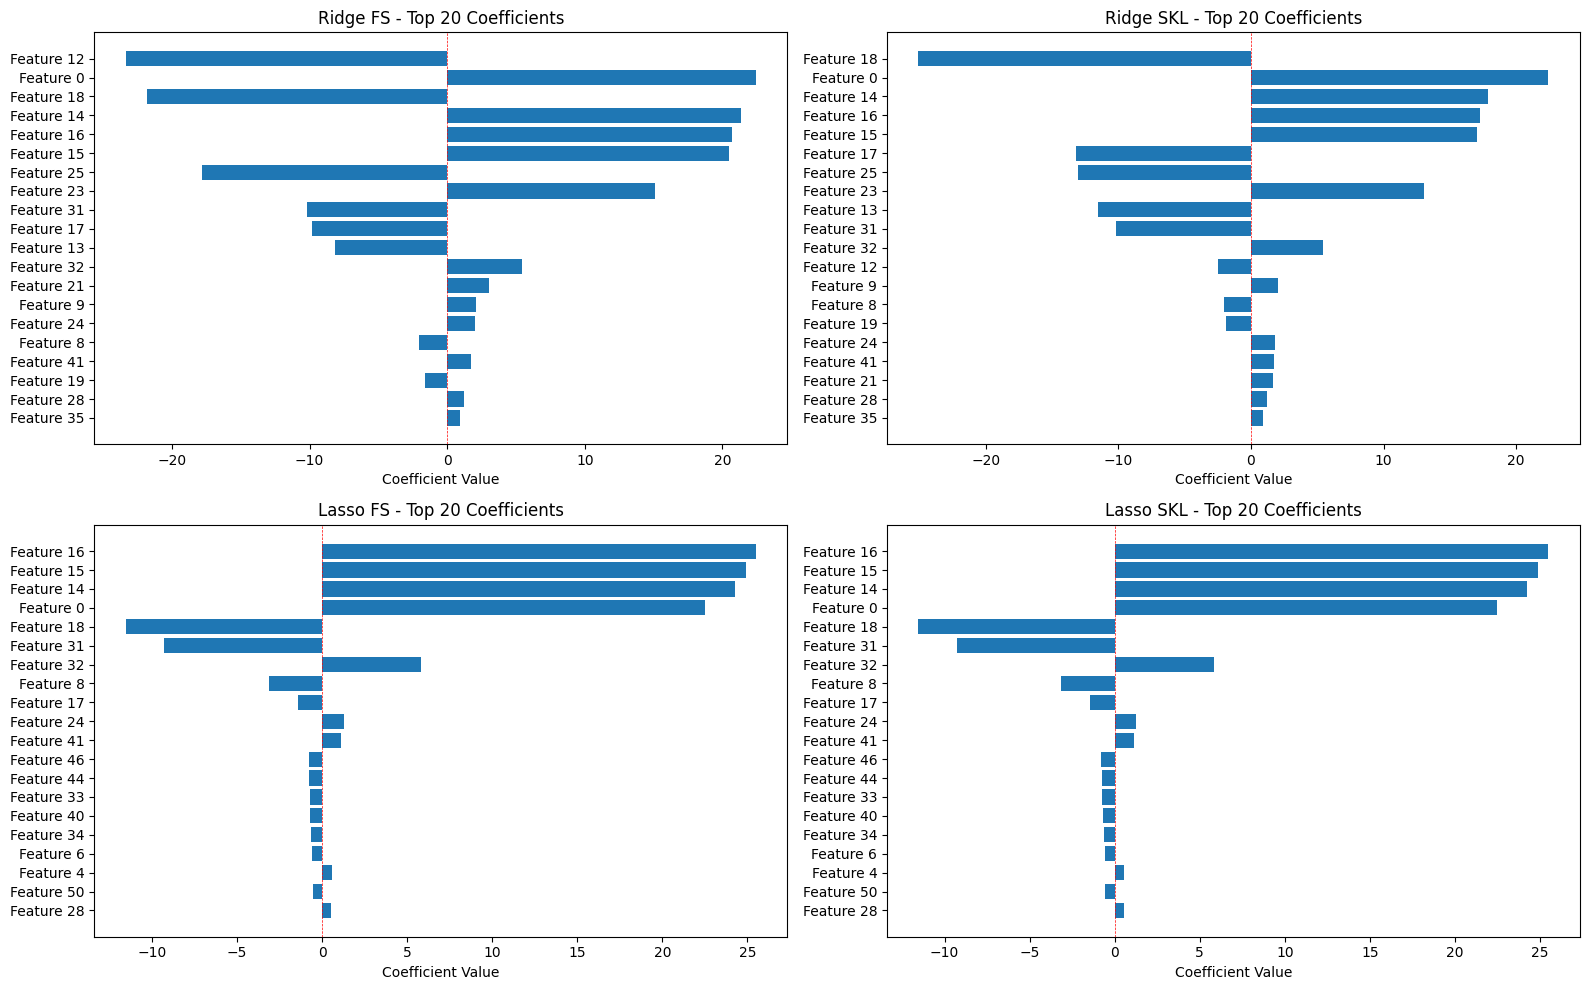


Sparsity Analysis (Zero Coefficients):
Ridge FS            :     1/   51 (  2.0% sparse)
Ridge SKL           :     1/   51 (  2.0% sparse)
Lasso FS            :    18/   51 ( 35.3% sparse)
Lasso SKL           :    20/   51 ( 39.2% sparse)


In [36]:
# 9.3 Análisis de coeficientes (feature importance)
print('\n' + '='*60)
print('COEFFICIENT ANALYSIS')
print('='*60)

# Comparar coeficientes de los mejores modelos
models_to_compare = [
    ('Ridge FS', best_ridge_model),
    ('Ridge SKL', ridge_grid.best_estimator_),
    ('Lasso FS', best_lasso_model),
    ('Lasso SKL', lasso_grid.best_estimator_)
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for idx, (name, model) in enumerate(models_to_compare):
    coefs = model.coef_
    n_features = min(20, len(coefs))  # Mostrar top 20
    top_idx = np.argsort(np.abs(coefs))[-n_features:]
    
    axes[idx].barh(range(n_features), coefs[top_idx])
    axes[idx].set_yticks(range(n_features))
    axes[idx].set_yticklabels([f'Feature {i}' for i in top_idx])
    axes[idx].set_xlabel('Coefficient Value')
    axes[idx].set_title(f'{name} - Top {n_features} Coefficients')
    axes[idx].axvline(0, color='red', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

# Contar coeficientes cero (sparsity)
print('\nSparsity Analysis (Zero Coefficients):')
for name, model in models_to_compare:
    n_zero = np.sum(np.abs(model.coef_) < 1e-10)
    n_total = len(model.coef_)
    sparsity = n_zero / n_total * 100
    print(f'{name:20s}: {n_zero:5d}/{n_total:5d} ({sparsity:5.1f}% sparse)')

## 10. Selección del Modelo Final y Evaluación en Test

Seleccionar el mejor modelo basado en RMSE de validación y evaluar en Test.

In [38]:
# 10.1 Seleccionar mejor modelo
print('='*60)
print('MODEL SELECTION')
print('='*60)

best_row = comparison_df.iloc[1]  # Excluir baseline (row 0)
best_model_name = best_row['Model']
best_rmse_val = best_row['RMSE']

print(f'✓ Best Model: {best_model_name}')
print(f'✓ Validation RMSE: {best_rmse_val:.4f}')

# Seleccionar el modelo correspondiente
if 'Ridge' in best_model_name and 'From-Scratch' in best_model_name:
    final_model = best_ridge_model
    final_model_sklearn = ridge_grid.best_estimator_
elif 'Ridge' in best_model_name and 'Scikit-Learn' in best_model_name:
    final_model = ridge_grid.best_estimator_
    final_model_sklearn = final_model
elif 'Lasso' in best_model_name and 'From-Scratch' in best_model_name:
    final_model = best_lasso_model
    final_model_sklearn = lasso_grid.best_estimator_
elif 'Lasso' in best_model_name and 'Scikit-Learn' in best_model_name:
    final_model = lasso_grid.best_estimator_
    final_model_sklearn = final_model
elif 'ElasticNet' in best_model_name and 'From-Scratch' in best_model_name:
    final_model = best_enet_model
    final_model_sklearn = enet_grid.best_estimator_
elif 'ElasticNet' in best_model_name and 'Scikit-Learn' in best_model_name:
    final_model = enet_grid.best_estimator_
    final_model_sklearn = final_model
elif 'SGD' in best_model_name and 'From-Scratch' in best_model_name:
    final_model = best_sgd_model
    final_model_sklearn = sgd_grid.best_estimator_
else:
    final_model = sgd_grid.best_estimator_
    final_model_sklearn = final_model

print(f'\n✓ Selected model for final evaluation')

MODEL SELECTION
✓ Best Model: Ridge (Scikit-Learn)
✓ Validation RMSE: 6.7738

✓ Selected model for final evaluation


In [39]:
# 10.2 Reentrenar en Train + Validation 
print('\n' + '='*60)
print('RETRAINING ON TRAIN + VALIDATION')
print('='*60)

# Combinar Train + Validation
X_trainval_prep = np.vstack([X_train_prep, X_valid_prep])
y_trainval = np.concatenate([y_train.values, y_valid.values])

print(f'Combined dataset: {X_trainval_prep.shape}')

# Reentrenar (usar modelo sklearn para producción)
if 'Scikit-Learn' in best_model_name or True:  # Usar sklearn para final
    start_time = time.time()
    
    # Crear nuevo modelo con los mejores parámetros
    if 'Ridge' in best_model_name:
        final_model_retrained = Ridge(**ridge_grid.best_params_, random_state=42)
    elif 'Lasso' in best_model_name:
        final_model_retrained = Lasso(**lasso_grid.best_params_, max_iter=1000, random_state=42)
    elif 'ElasticNet' in best_model_name:
        final_model_retrained = ElasticNet(**enet_grid.best_params_, max_iter=1000, random_state=42)
    else:
        final_model_retrained = SGDRegressor(**sgd_grid.best_params_, max_iter=500, 
                                             early_stopping=True, random_state=42)
    
    final_model_retrained.fit(X_trainval_prep, y_trainval)
    retrain_time = time.time() - start_time
    
    print(f'✓ Retrained in {retrain_time:.2f}s')
else:
    final_model_retrained = final_model
    print('✓ Using validation model (no retraining)')



RETRAINING ON TRAIN + VALIDATION
Combined dataset: (1199509, 51)
✓ Retrained in 1.19s
✓ Retrained in 1.19s


In [40]:
# 10.3 Evaluación final en Test
print('\n' + '='*80)
print('FINAL EVALUATION ON TEST SET (2025)')
print('='*80)

# Predicción
y_pred_test = final_model_retrained.predict(X_test_prep)

# Métricas
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print(f'\nModel: {best_model_name}')
print(f'\nTest Set Metrics:')
print(f'  RMSE: ${rmse_test:.4f}')
print(f'  MAE:  ${mae_test:.4f}')
print(f'  R²:   {r2_test:.4f}')
print(f'\n  Model explains {r2_test*100:.1f}% of variance in unseen 2025 data')
print(f'  Average prediction error: ${mae_test:.2f}')

# Comparar con baseline
improvement_rmse = (rmse_baseline - rmse_test) / rmse_baseline * 100
improvement_mae = (mae_baseline - mae_test) / mae_baseline * 100

print(f'\nImprovement over Baseline:')
print(f'  RMSE: {improvement_rmse:.1f}% better')
print(f'  MAE:  {improvement_mae:.1f}% better')

print('\n' + '='*80)



FINAL EVALUATION ON TEST SET (2025)

Model: Ridge (Scikit-Learn)

Test Set Metrics:
  RMSE: $6.7755
  MAE:  $3.8902
  R²:   0.9116

  Model explains 91.2% of variance in unseen 2025 data
  Average prediction error: $3.89

Improvement over Baseline:
  RMSE: 70.3% better
  MAE:  74.1% better


Model: Ridge (Scikit-Learn)

Test Set Metrics:
  RMSE: $6.7755
  MAE:  $3.8902
  R²:   0.9116

  Model explains 91.2% of variance in unseen 2025 data
  Average prediction error: $3.89

Improvement over Baseline:
  RMSE: 70.3% better
  MAE:  74.1% better

